# Titanic Survival Prediction

This notebook builds a classification model to predict passenger survival on the Titanic using the classic Kaggle dataset. The goal is to explore which passenger attributes (class, sex, age, family size, fare, etc.) were most associated with survival, engineer useful features from raw data, and train/evaluate models that generalize well to unseen passengers.

**Workflow:** EDA → Feature Engineering → Preprocessing Pipeline → Model Training (Logistic Regression & Random Forest) → Cross-Validation → Hyperparameter Tuning → Final Evaluation → Kaggle Submission.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## 1. Data Overview

Loading the training set (with `Survived` labels) and the test set (unlabeled, used only for the final Kaggle submission). A quick look at structure, data types, and summary statistics helps confirm the data loaded correctly and flags immediate issues (e.g. missing values, unexpected types).

In [3]:
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Class Balance Check

In [5]:
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

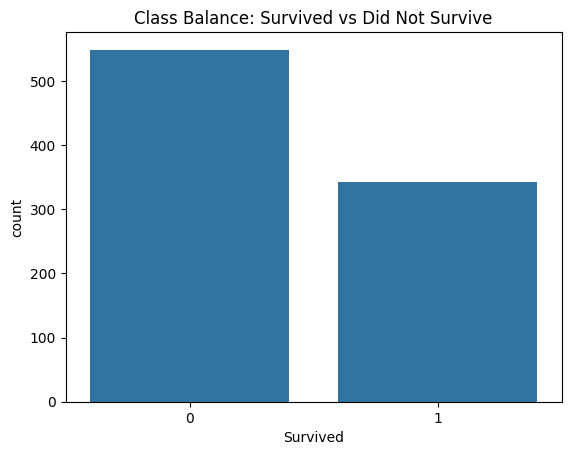

In [6]:
sns.countplot(x="Survived", data=train)
plt.title("Class Balance: Survived vs Did Not Survive")
plt.show()

**Observation:** About 62% of passengers in the training set did not survive, versus 38% who did. This is a mild class imbalance — not severe enough to require resampling techniques (like SMOTE), but worth keeping in mind when interpreting accuracy: a naive model that always predicts "did not survive" would already score ~62% accuracy, so our models need to clear that baseline meaningfully.

### Feature Engineering: Title (from Name) and AgeGroup (binned Age)

In [7]:
# Extract Title from Name (e.g. "Braund, Mr. Owen Harris" -> "Mr")
train['Title'] = train['Name'].str.extract(r',\s*([^.]+)\.')
test['Title'] = test['Name'].str.extract(r',\s*([^.]+)\.')

# Group rare/foreign titles into consistent buckets
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
}
train['Title'] = train['Title'].map(title_map).fillna('Rare')
test['Title'] = test['Title'].map(title_map).fillna('Rare')

train['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

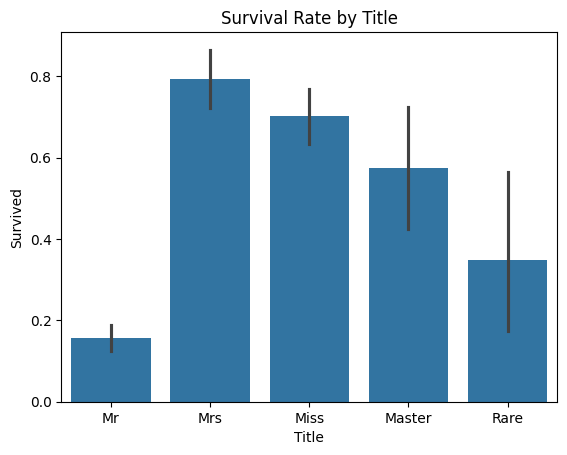

In [8]:
sns.barplot(x="Title", y="Survived", data=train)
plt.title("Survival Rate by Title")
plt.show()

**Observation:** `Title` extracted from each passenger's name is a strong signal on its own. `Mr` has a notably lower survival rate than `Mrs`/`Miss`, consistent with "women and children first" evacuation priority. `Master` (young boys) also shows elevated survival relative to `Mr`, capturing age-related priority that raw `Age` alone (with many missing values) can't fully express.

In [9]:
# Bin Age into groups (helps capture non-linear age effects, e.g. children prioritized)
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train['Age'], bins=bins, labels=labels)
test['AgeGroup'] = pd.cut(test['Age'], bins=bins, labels=labels)

train.groupby('AgeGroup', observed=True)['Survived'].mean()

AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.382682
Adult         0.400000
Senior        0.227273
Name: Survived, dtype: float64

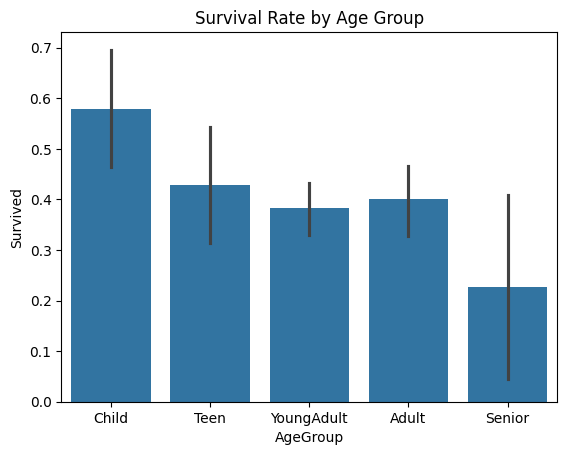

In [10]:
sns.barplot(x="AgeGroup", y="Survived", data=train, order=labels)
plt.title("Survival Rate by Age Group")
plt.show()

**Observation:** Binning `Age` into life-stage groups makes the survival pattern easier to read than the raw continuous variable: children have the highest survival rate, and it generally declines through adulthood into the senior group — reinforcing the "children first" pattern seen in `Title`.

## 2. Exploratory Data Analysis: Core Features

Examining survival rate across the primary demographic and travel features to identify which are likely to carry predictive signal.

<Axes: xlabel='Sex', ylabel='Survived'>

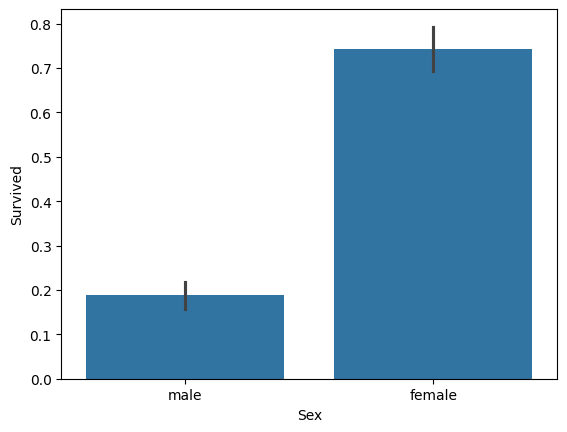

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="Sex", y="Survived", data=train)

<Axes: xlabel='Pclass', ylabel='Survived'>

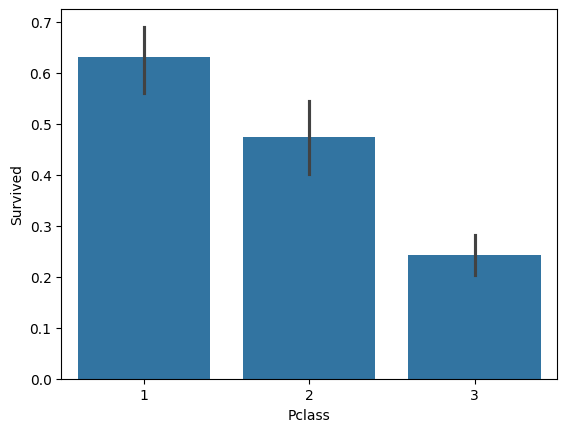

In [12]:

sns.barplot(x="Pclass", y="Survived", data=train)

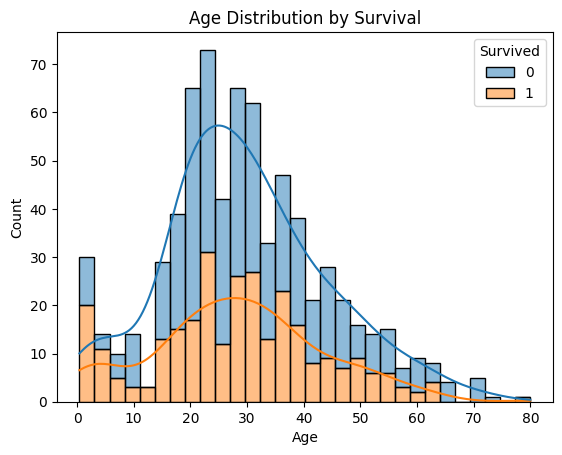

In [13]:
sns.histplot(data=train, x="Age", hue="Survived", multiple="stack", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

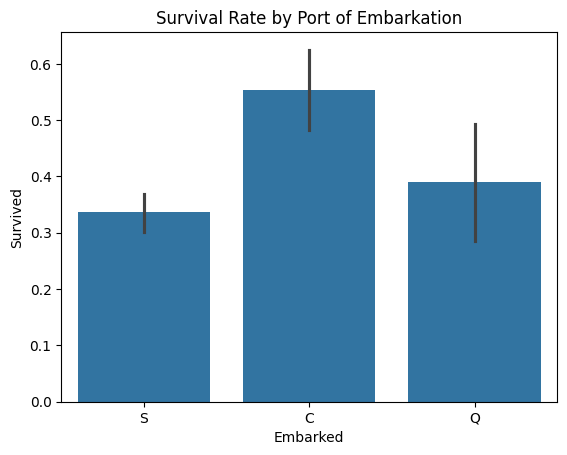

In [14]:
sns.barplot(x="Embarked", y="Survived", data=train)
plt.title("Survival Rate by Port of Embarkation")
plt.show()

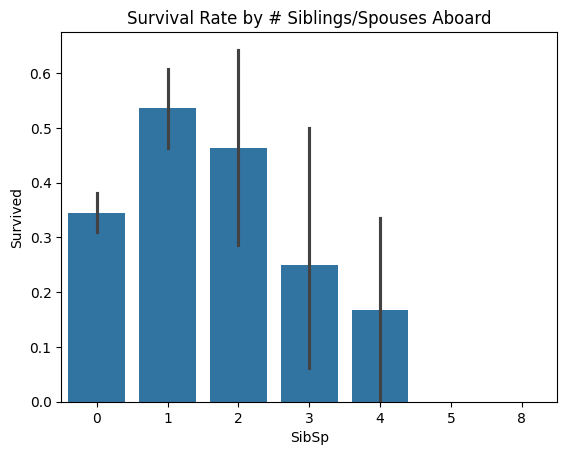

In [15]:
sns.barplot(x="SibSp", y="Survived", data=train)
plt.title("Survival Rate by # Siblings/Spouses Aboard")
plt.show()

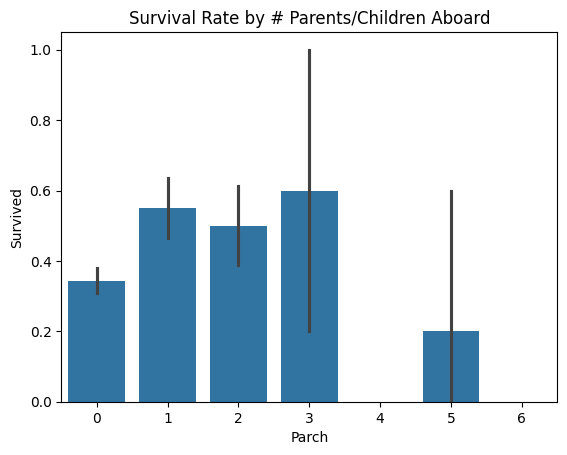

In [16]:
sns.barplot(x="Parch", y="Survived", data=train)
plt.title("Survival Rate by # Parents/Children Aboard")
plt.show()

**EDA Summary:** Across all features examined, three stand out as strong survival predictors: **Sex** (women survived at a much higher rate than men), **Pclass** (1st class passengers fared better than 3rd class, reflecting cabin location and lifeboat access), and **Title/AgeGroup** (children and women prioritized in evacuation). `Embarked`, `SibSp`, and `Parch` show weaker but still noticeable patterns — e.g. passengers traveling with a small family tended to survive more often than those completely alone or in very large families.

## 3. Data Preparation for Modeling

Before training, the data needs to be split into train/test sets and passed through a preprocessing pipeline that:
- Imputes missing values (`Age` → median, categorical fields → most frequent)
- One-hot encodes categorical features (`Sex`, `Embarked`, `Title`, `AgeGroup`)
- Passes numeric features (`Fare`, `SibSp`, `Parch`) through as-is

Using a `scikit-learn` `Pipeline` + `ColumnTransformer` keeps preprocessing consistent between training, cross-validation, and the final test-set predictions — avoiding data leakage.

In [17]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [18]:
from sklearn.model_selection import train_test_split

X = train.drop("Survived", axis=1)
y = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [20]:
age_feature = ['Age']
age_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('age', age_transformer, age_feature)]
)


In [22]:
categorical_features = ["Sex", "Embarked", "Title", "AgeGroup"]
numeric_features = ["Fare", "SibSp", "Parch"]

In [23]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [24]:
preprocessor = ColumnTransformer([
    ("age", age_transformer, age_feature),
    ("cat", categorical_pipeline, categorical_features),
    ("num", numeric_pipeline, numeric_features)
])

## 4. Model Building

Training two baseline classifiers — **Logistic Regression** (a simple, interpretable linear model) and **Random Forest** (a non-linear ensemble that can capture feature interactions) — using identical preprocessing so the comparison is fair.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42)
}

In [26]:
results = {}
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    print(f"Fitting {model_name}...")
    pipe.fit(X_train, y_train)
    print(f"Scoring {model_name}...")

    results[model_name] = pipe.score(X_test, y_test)
    fitted_pipelines[model_name] = pipe

print(results)

Fitting Logistic...
Scoring Logistic...
Fitting RandomForest...
Scoring RandomForest...
{'Logistic': 0.8100558659217877, 'RandomForest': 0.8044692737430168}


In [27]:
# Evaluate each fitted model explicitly instead of relying on the last "pipe" from the loop
for model_name, fitted_pipe in fitted_pipelines.items():
    y_pred = fitted_pipe.predict(X_test)
    print(f"{model_name} accuracy: {accuracy_score(y_test, y_pred):.4f}")

Logistic accuracy: 0.8101


RandomForest accuracy: 0.8045


**Observation:** On this single train/test split, Logistic Regression (0.810) and Random Forest (0.805) perform almost identically. A single split can still be misleading — the next step (cross-validation) gives a more reliable comparison.

In [29]:
cv_results = {}

for model_name, model in models.items():
    cv_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(cv_pipe, X, y, cv=5, scoring="accuracy")
    cv_results[model_name] = scores
    print(f"{model_name} CV Scores:", scores)
    print(f"{model_name} Mean Accuracy: {scores.mean():.4f}\n")

Logistic CV Scores: [0.82681564 0.82022472 0.79775281 0.79213483 0.85955056]
Logistic Mean Accuracy: 0.8193



RandomForest CV Scores: [0.79329609 0.78651685 0.81460674 0.75280899 0.80337079]
RandomForest Mean Accuracy: 0.7901



**Observation:** Cross-validation confirms Logistic Regression is the more reliable model here: mean CV accuracy of 0.819 versus Random Forest's 0.790, and Logistic's fold-to-fold scores are also more consistent. **Takeaway:** always trust cross-validated scores over a single split when comparing models — Random Forest's single-split number looked competitive, but its CV performance shows it's actually the weaker of the two on this dataset in its default configuration.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

## 5. Detailed Evaluation (Logistic Regression)

Beyond accuracy, precision, recall, and the confusion matrix give a fuller picture of model quality — particularly important here since the classes are imbalanced and the cost of missing an actual survivor (false negative) may matter more than a false positive, depending on the use case.

In [31]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
Confusion Matrix:
 [[90 15]
 [19 55]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Observation:** Precision (survivors correctly predicted, of those predicted to survive) is higher than recall (survivors correctly predicted, of those who actually survived) — the model is somewhat conservative, missing roughly 1 in 4 actual survivors. This is a reasonable balance for a first-pass model but could be tuned further depending on whether false negatives or false positives are more costly for the use case.

## 6. Hyperparameter Tuning

Using `GridSearchCV` to search over Logistic Regression's regularization strength (`C`) and solver, with 5-fold cross-validation, to see whether tuning improves on the default configuration.

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [35]:
log_reg_grid = {
    "model__C": np.logspace(-4, 4, 20),
    "model__solver": ["liblinear"]
}

In [36]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=log_reg_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([1.0000...00000000e+04]), 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [37]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_) 

Best Params: {'model__C': np.float64(1.623776739188721), 'model__solver': 'liblinear'}
Best Score: 0.8258051807347583


**Observation:** GridSearchCV found `C ≈ 1.62` with the `liblinear` solver as the best configuration, reaching a CV accuracy of 0.826 — only marginally above the untuned Logistic Regression's 0.819. This isn't surprising: `C` and solver choice are minor adjustments for logistic regression, and this dataset's relationship between features and survival is already close to what the default linear model captures.

### Final Model: Evaluate Using GridSearchCV's Best Hyperparameters

In [38]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
Confusion Matrix:
 [[90 15]
 [19 55]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Observation:** Because the tuned hyperparameters were so close to the defaults, the final evaluation metrics are effectively unchanged from the earlier baseline Logistic Regression run — confirming that hyperparameter tuning had limited room to improve this particular model/dataset combination.

In [39]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[90, 15],
       [19, 55]])

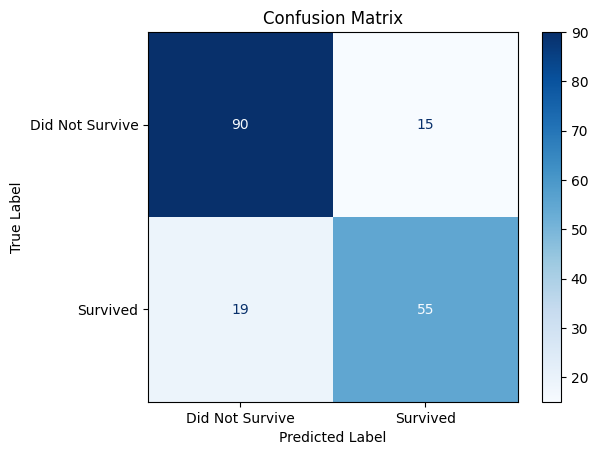

In [ ]:
# Create a more visual confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"] 
)

disp.plot(cmap="Blues")  
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 7. Final Predictions & Submission

With the best model selected and validated, it's refit on **all** available labeled data (not just the training split) to make use of every labeled example before generating predictions on the true holdout `test.csv` set — producing a `submission.csv` in the format Kaggle expects (`PassengerId`, `Survived`).

### Final Predictions on `test.csv` 

In [41]:
final_model = grid.best_estimator_
final_model.fit(X, y)

test_predictions = final_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})
submission.to_csv("submission.csv", index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Conclusion & Next Steps

**Summary:** Logistic Regression and Random Forest both reach ~80-82% accuracy on this dataset, with cross-validation favoring Logistic Regression as the more reliable of the two untuned models. Hyperparameter tuning on Logistic Regression yielded only a marginal improvement, suggesting the current feature set is close to fully exploited by a linear model.

**Key predictive features:** `Sex`, `Pclass`, `Title`, and `AgeGroup` showed the clearest relationships with survival, consistent with the historical "women and children first" evacuation pattern and the advantage of higher-class passengers.

**Possible improvements for future iterations:**
- Tune Random Forest (e.g. `n_estimators`, `max_depth`) via `GridSearchCV` for a fair comparison against the tuned Logistic Regression
- Engineer `FamilySize` (`SibSp` + `Parch` + 1) and `IsAlone` features, known to be predictive on this dataset
- Try gradient boosting (XGBoost/LightGBM) as a stronger non-linear baseline
- Inspect Random Forest feature importances to validate which engineered features are actually driving predictions